In [18]:
!pip install pandas numpy matplotlib seaborn scipy gdown -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
print("✅ Done")

✅ Done


In [19]:
import gdown

# Historical Trader Data
gdown.download(
    'https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs',
    '/content/trades.csv', quiet=False
)

# Fear & Greed Index
gdown.download(
    'https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf',
    '/content/fear_greed.csv', quiet=False
)

print("✅ Files downloaded")

Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/trades.csv
100%|██████████| 47.5M/47.5M [00:00<00:00, 93.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/fear_greed.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 63.1MB/s]

✅ Files downloaded


In [20]:
df_trades = pd.read_csv('/content/trades.csv')
df_fg     = pd.read_csv('/content/fear_greed.csv')

print("=== TRADES ===")
print(df_trades.shape)
print(df_trades.head(3))
print(df_trades.dtypes)

print("\n=== FEAR & GREED ===")
print(df_fg.shape)
print(df_fg.head(3))
print(df_fg.dtypes)

=== TRADES ===
(211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Timestamp 

In [21]:
# Standardize column names
df_trades.columns = (df_trades.columns
                     .str.strip()
                     .str.lower()
                     .str.replace(' ', '_')
                     .str.replace('/', '_'))

df_fg.columns = (df_fg.columns
                 .str.strip()
                 .str.lower()
                 .str.replace(' ', '_'))

print("Trades cols:", df_trades.columns.tolist())
print("FG cols:    ", df_fg.columns.tolist())

# Convert numeric columns
for col in ['closed_pnl', 'size_usd', 'size_tokens', 'execution_price', 'fee']:
    if col in df_trades.columns:
        df_trades[col] = pd.to_numeric(df_trades[col], errors='coerce')

# Standardize Side/Direction
for col in ['side', 'direction']:
    if col in df_trades.columns:
        df_trades[col] = df_trades[col].str.strip().str.upper()

print("\n✅ Cleaned")
print(df_trades.describe())

Trades cols: ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']
FG cols:     ['timestamp', 'value', 'classification', 'date']

✅ Cleaned
       execution_price   size_tokens      size_usd  start_position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          closed_pnl      order_id            fee      trade_id     time

In [22]:
# Find the right timestamp column
ts_col = None
for c in ['timestamp_ist', 'timestamp', 'time']:
    if c in df_trades.columns:
        ts_col = c
        break

print(f"Timestamp column: {ts_col}")
print("Sample:", df_trades[ts_col].head(3).tolist())

# Parse — try multiple formats
df_trades['datetime'] = pd.to_datetime(df_trades[ts_col], errors='coerce', infer_datetime_format=True)
df_trades['date']     = df_trades['datetime'].dt.normalize()  # midnight UTC

# Parse Fear & Greed dates
df_fg['date'] = pd.to_datetime(df_fg['date'], errors='coerce', infer_datetime_format=True)

# Standardize sentiment label
sent_col = 'classification' if 'classification' in df_fg.columns else df_fg.columns[1]
df_fg.rename(columns={sent_col: 'sentiment'}, inplace=True)
df_fg['sentiment'] = df_fg['sentiment'].str.strip().str.title()

print("\nDate range trades:", df_trades['date'].min(), "→", df_trades['date'].max())
print("Date range FG:    ", df_fg['date'].min(), "→", df_fg['date'].max())
print("\nSentiment values:\n", df_fg['sentiment'].value_counts())

Timestamp column: timestamp_ist
Sample: ['02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50']

Date range trades: 2023-01-05 00:00:00 → 2025-12-04 00:00:00
Date range FG:     2018-02-01 00:00:00 → 2025-05-02 00:00:00

Sentiment values:
 sentiment
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [23]:
df = df_trades.merge(df_fg[['date', 'sentiment']], on='date', how='left')

print(f"Merged rows:              {len(df):,}")
print(f"Rows WITH sentiment:      {df['sentiment'].notna().sum():,}")
print(f"Rows WITHOUT sentiment:   {df['sentiment'].isna().sum():,}")
print("\nSentiment in merged data:")
print(df['sentiment'].value_counts())

Merged rows:              211,224
Rows WITH sentiment:      35,864
Rows WITHOUT sentiment:   175,360

Sentiment in merged data:
sentiment
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


=== OVERALL STATS ===
Total trades:    211,224
Unique traders:  32
Unique coins:    246
Total PnL:       $10,296,958.94
Avg PnL/trade:   $48.7490
Overall win rate:41.1%


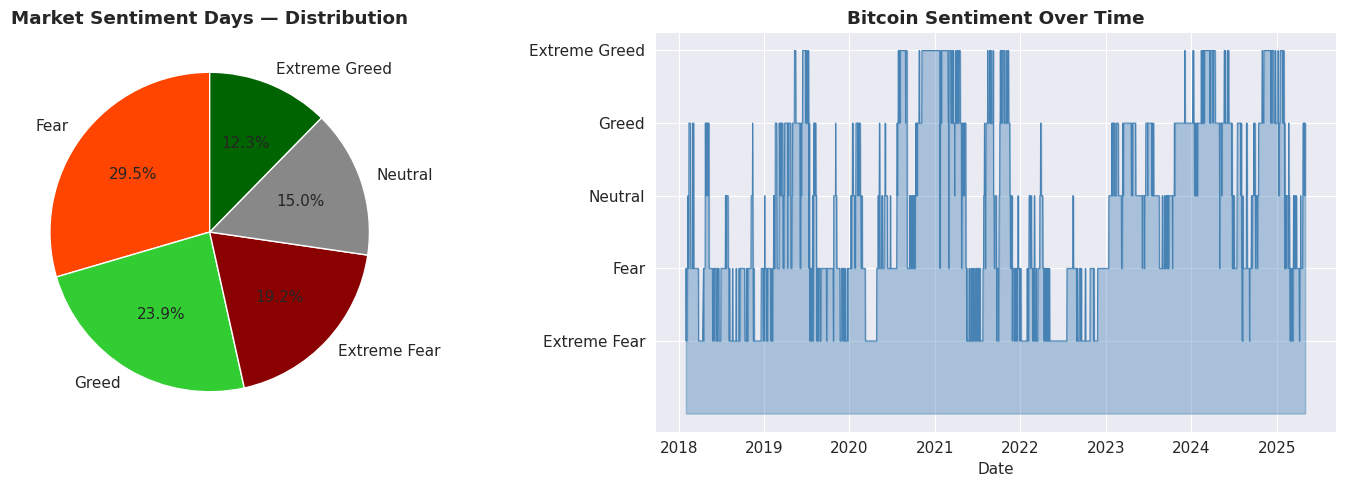

In [24]:
print("=== OVERALL STATS ===")
print(f"Total trades:    {len(df):,}")
print(f"Unique traders:  {df['account'].nunique():,}")
print(f"Unique coins:    {df['coin'].nunique():,}")
print(f"Total PnL:       ${df['closed_pnl'].sum():,.2f}")
print(f"Avg PnL/trade:   ${df['closed_pnl'].mean():.4f}")
print(f"Overall win rate:{(df['closed_pnl'] > 0).mean()*100:.1f}%")

# ---- Sentiment pie + timeline ----
color_map = {
    'Extreme Fear': '#8B0000',
    'Fear':         '#FF4500',
    'Neutral':      '#888888',
    'Greed':        '#32CD32',
    'Extreme Greed':'#006400'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df_fg['sentiment'].value_counts()
clrs   = [color_map.get(s, 'grey') for s in counts.index]
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=clrs, startangle=90)
axes[0].set_title('Market Sentiment Days — Distribution', fontweight='bold')

sent_num = {'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 'Greed': 4, 'Extreme Greed': 5}
df_fg['snum'] = df_fg['sentiment'].map(sent_num)
axes[1].fill_between(df_fg['date'], df_fg['snum'], alpha=0.4, color='steelblue')
axes[1].plot(df_fg['date'], df_fg['snum'], linewidth=0.7, color='steelblue')
axes[1].set_yticks([1,2,3,4,5])
axes[1].set_yticklabels(['Extreme Fear','Fear','Neutral','Greed','Extreme Greed'])
axes[1].set_title('Bitcoin Sentiment Over Time', fontweight='bold')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('/content/01_sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()

=== PnL BY SENTIMENT ===
    sentiment    total_pnl    avg_pnl  median_pnl  trade_count  win_rate   total_vol
 Extreme Fear 4.399937e+03   1.891632     0.00000         2326 29.277730  9580240.04
         Fear 1.779226e+06 128.287950     0.00000        13869 38.178672 79674391.06
      Neutral 7.465674e+04  27.088803     0.00000         2756 49.492017 11939551.21
        Greed 6.096325e+05  53.988003     0.00000        11292 43.570670 57045815.74
Extreme Greed 1.156894e+06 205.816345     0.96048         5621 55.328233 18223760.27


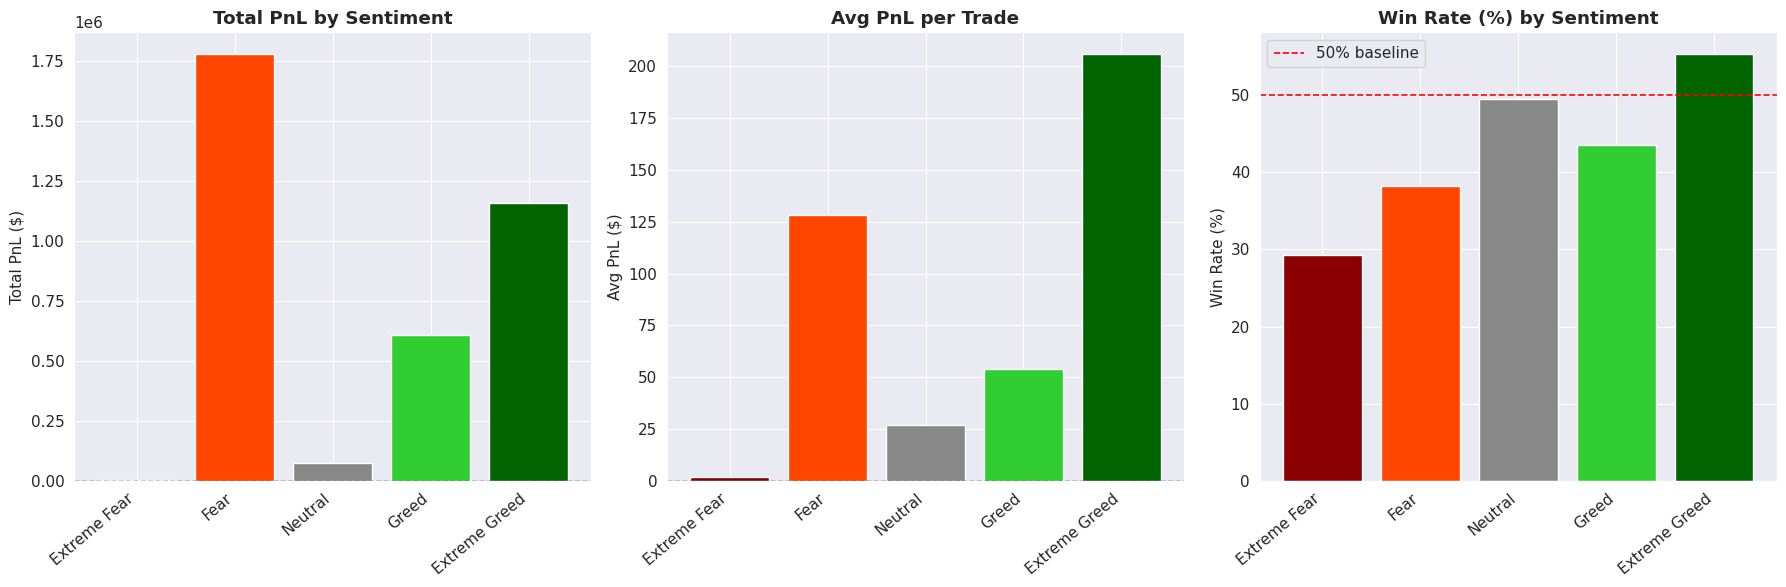

In [25]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
existing_order  = [s for s in sentiment_order if s in df['sentiment'].values]

pnl_stats = (df.groupby('sentiment', observed=True)
               .agg(
                   total_pnl  = ('closed_pnl', 'sum'),
                   avg_pnl    = ('closed_pnl', 'mean'),
                   median_pnl = ('closed_pnl', 'median'),
                   trade_count= ('closed_pnl', 'count'),
                   win_rate   = ('closed_pnl', lambda x: (x > 0).mean() * 100),
                   total_vol  = ('size_usd', 'sum') if 'size_usd' in df.columns else ('closed_pnl','count')
               )
               .reindex(existing_order)
               .reset_index())

print("=== PnL BY SENTIMENT ===")
print(pnl_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bar_colors = [color_map.get(s, 'grey') for s in pnl_stats['sentiment']]

# Total PnL
axes[0].bar(pnl_stats['sentiment'], pnl_stats['total_pnl'], color=bar_colors)
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].set_title('Total PnL by Sentiment', fontweight='bold')
axes[0].set_xticklabels(pnl_stats['sentiment'], rotation=40, ha='right')
axes[0].set_ylabel('Total PnL ($)')

# Avg PnL per Trade
axes[1].bar(pnl_stats['sentiment'], pnl_stats['avg_pnl'], color=bar_colors)
axes[1].axhline(0, color='black', lw=1, linestyle='--')
axes[1].set_title('Avg PnL per Trade', fontweight='bold')
axes[1].set_xticklabels(pnl_stats['sentiment'], rotation=40, ha='right')
axes[1].set_ylabel('Avg PnL ($)')

# Win Rate
axes[2].bar(pnl_stats['sentiment'], pnl_stats['win_rate'], color=bar_colors)
axes[2].axhline(50, color='red', lw=1.2, linestyle='--', label='50% baseline')
axes[2].set_title('Win Rate (%) by Sentiment', fontweight='bold')
axes[2].set_xticklabels(pnl_stats['sentiment'], rotation=40, ha='right')
axes[2].set_ylabel('Win Rate (%)')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/02_pnl_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

=== LONG vs SHORT by SENTIMENT ===
    sentiment side    avg_pnl     total_pnl  count
 Extreme Fear  BUY  -3.248825 -3.794627e+03   1168
 Extreme Fear SELL   7.076480  8.194564e+03   1158
Extreme Greed  BUY   9.047055  1.502716e+04   1661
Extreme Greed SELL 288.350131  1.141867e+06   3960
         Fear  BUY 210.426466  1.537586e+06   7307
         Fear SELL  36.824047  2.416394e+05   6562
        Greed  BUY  15.661324  8.468078e+04   5407
        Greed SELL  89.201657  5.249518e+05   5885
      Neutral  BUY  12.484274  1.273396e+04   1020
      Neutral SELL  35.669805  6.192278e+04   1736


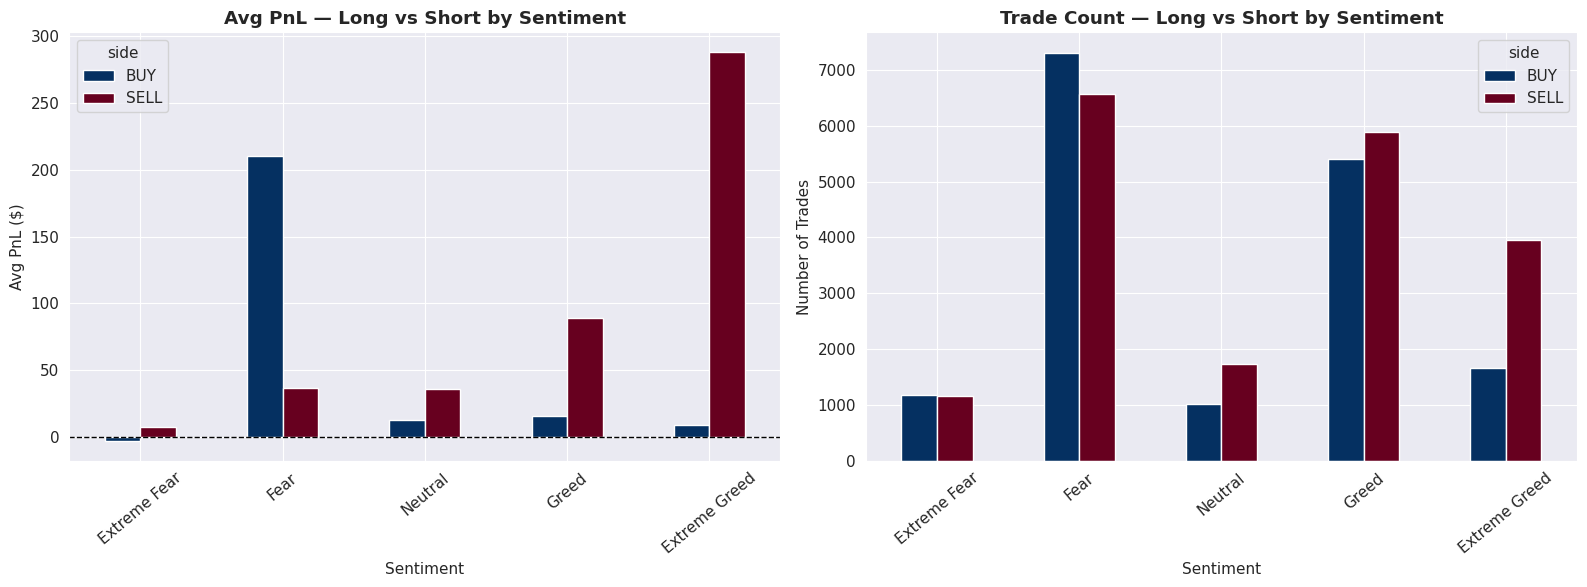

In [26]:
side_col = 'side' if 'side' in df.columns else 'direction'

ls = (df.groupby(['sentiment', side_col], observed=True)['closed_pnl']
        .agg(['mean', 'sum', 'count'])
        .reset_index())
ls.columns = ['sentiment', 'side', 'avg_pnl', 'total_pnl', 'count']

print("=== LONG vs SHORT by SENTIMENT ===")
print(ls.to_string(index=False))

pivot_avg = ls.pivot(index='sentiment', columns='side', values='avg_pnl').reindex(existing_order)
pivot_cnt = ls.pivot(index='sentiment', columns='side', values='count').reindex(existing_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_avg.plot(kind='bar', ax=axes[0], colormap='RdBu_r')
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].set_title('Avg PnL — Long vs Short by Sentiment', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Avg PnL ($)')
axes[0].tick_params(axis='x', rotation=40)

pivot_cnt.plot(kind='bar', ax=axes[1], colormap='RdBu_r')
axes[1].set_title('Trade Count — Long vs Short by Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Trades')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('/content/03_long_short_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

=== CONTRARIAN vs MOMENTUM ===
      behavior    avg_pnl    total_pnl  trade_count  win_rate
    Contrarian 129.995185 3.300318e+06        25388 41.657476
      Momentum  32.361912 2.498340e+05         7720 44.430052
Neutral Period  37.878726 6.746807e+06       178116 40.907611


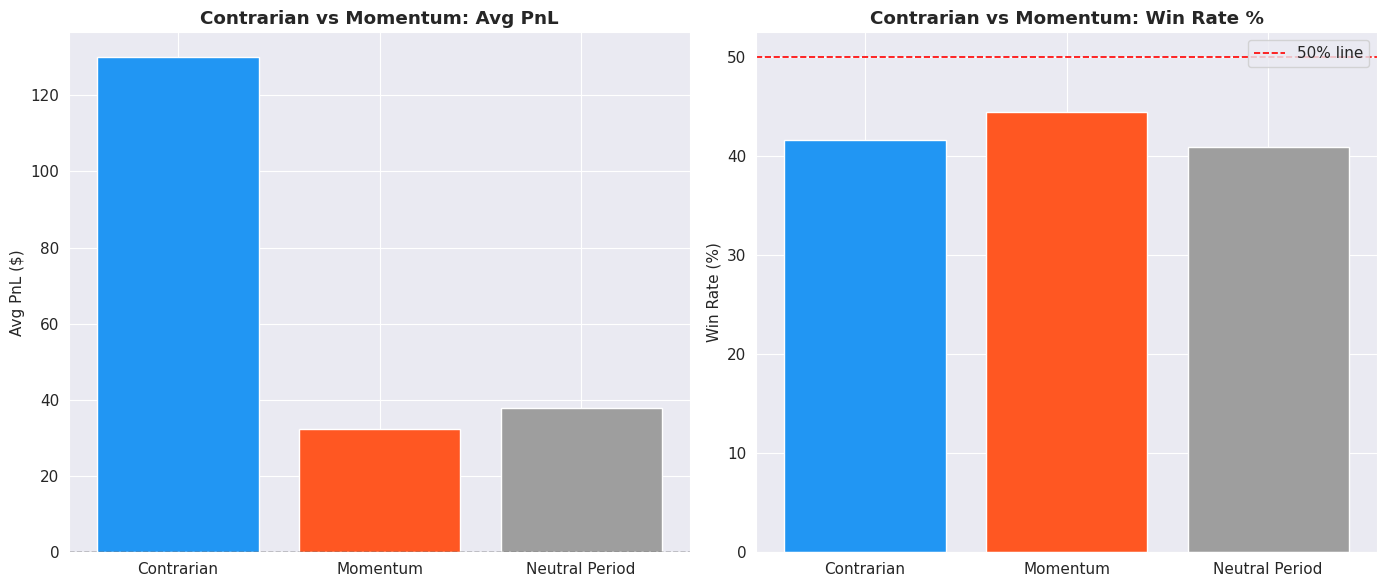

In [27]:
# CONTRARIAN = buy during Fear / sell during Greed
# MOMENTUM   = buy during Greed / sell during Fear

def label_behavior(row):
    s = str(row.get('sentiment', '')).lower()
    t = str(row.get(side_col, '')).lower()
    if 'fear' in s:
        return 'Contrarian' if ('buy' in t or 'long' in t or 'a' in t) else 'Momentum'
    elif 'greed' in s:
        return 'Contrarian' if ('sell' in t or 'short' in t or 'b' in t) else 'Momentum'
    return 'Neutral Period'

df['behavior'] = df.apply(label_behavior, axis=1)

beh_stats = df.groupby('behavior').agg(
    avg_pnl    = ('closed_pnl', 'mean'),
    total_pnl  = ('closed_pnl', 'sum'),
    trade_count= ('closed_pnl', 'count'),
    win_rate   = ('closed_pnl', lambda x: (x > 0).mean() * 100)
).reset_index()

print("=== CONTRARIAN vs MOMENTUM ===")
print(beh_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

beh_colors = {'Contrarian': '#2196F3', 'Momentum': '#FF5722', 'Neutral Period': '#9E9E9E'}
colors_b    = [beh_colors.get(b, 'grey') for b in beh_stats['behavior']]

axes[0].bar(beh_stats['behavior'], beh_stats['avg_pnl'], color=colors_b)
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].set_title('Contrarian vs Momentum: Avg PnL', fontweight='bold')
axes[0].set_ylabel('Avg PnL ($)')

axes[1].bar(beh_stats['behavior'], beh_stats['win_rate'], color=colors_b)
axes[1].axhline(50, color='red', lw=1.2, linestyle='--', label='50% line')
axes[1].set_title('Contrarian vs Momentum: Win Rate %', fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/04_contrarian_momentum.png', dpi=150, bbox_inches='tight')
plt.show()

=== LAG EFFECT: Today's Sentiment → Tomorrow's Avg PnL ===
               next_day_avg_pnl  next_day_total_pnl
sentiment                                          
Extreme Fear          53.717168        61692.653321
Fear                  49.362503        43060.565362
Neutral               45.980420         9958.781702
Greed                 36.794003        21006.767352
Extreme Greed         33.799104        13837.686466


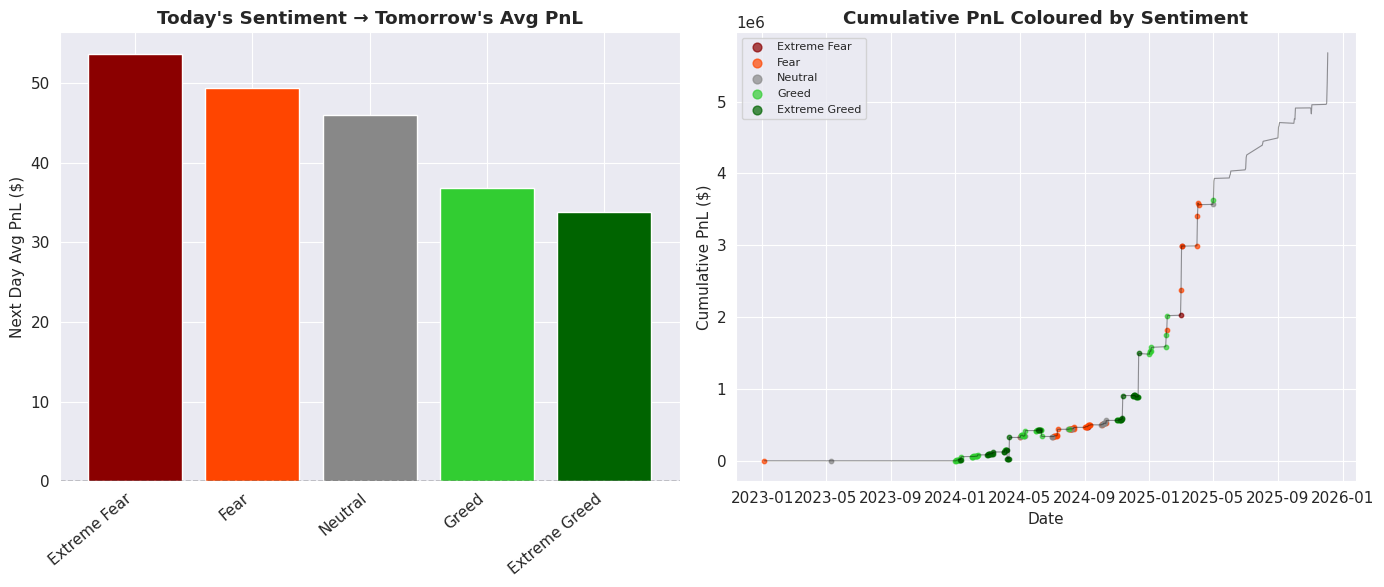

In [28]:
# Does TODAY'S sentiment predict TOMORROW'S performance?

daily = (df.groupby('date')
           .agg(daily_pnl   = ('closed_pnl', 'sum'),
                avg_pnl     = ('closed_pnl', 'mean'),
                trade_count = ('closed_pnl', 'count'))
           .reset_index()
           .sort_values('date'))

daily = daily.merge(df_fg[['date', 'sentiment']], on='date', how='left')
daily['next_day_avg_pnl']   = daily['avg_pnl'].shift(-1)
daily['next_day_total_pnl'] = daily['daily_pnl'].shift(-1)

lag = daily.groupby('sentiment')[['next_day_avg_pnl', 'next_day_total_pnl']].mean().reindex(existing_order)
print("=== LAG EFFECT: Today's Sentiment → Tomorrow's Avg PnL ===")
print(lag)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lag_colors = [color_map.get(s, 'grey') for s in lag.index]
axes[0].bar(lag.index, lag['next_day_avg_pnl'], color=lag_colors)
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].set_title("Today's Sentiment → Tomorrow's Avg PnL", fontweight='bold')
axes[0].set_xticklabels(lag.index, rotation=40, ha='right')
axes[0].set_ylabel('Next Day Avg PnL ($)')

# Cumulative PnL over time coloured by sentiment
daily_cum = daily.copy()
daily_cum['cum_pnl'] = daily_cum['daily_pnl'].cumsum()

for s in existing_order:
    mask = daily_cum['sentiment'] == s
    axes[1].scatter(daily_cum.loc[mask, 'date'],
                    daily_cum.loc[mask, 'cum_pnl'],
                    c=color_map.get(s, 'grey'), s=10, label=s, alpha=0.7)

axes[1].plot(daily_cum['date'], daily_cum['cum_pnl'], color='black', lw=0.8, alpha=0.4)
axes[1].set_title('Cumulative PnL Coloured by Sentiment', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative PnL ($)')
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig('/content/05_lag_effect.png', dpi=150, bbox_inches='tight')
plt.show()

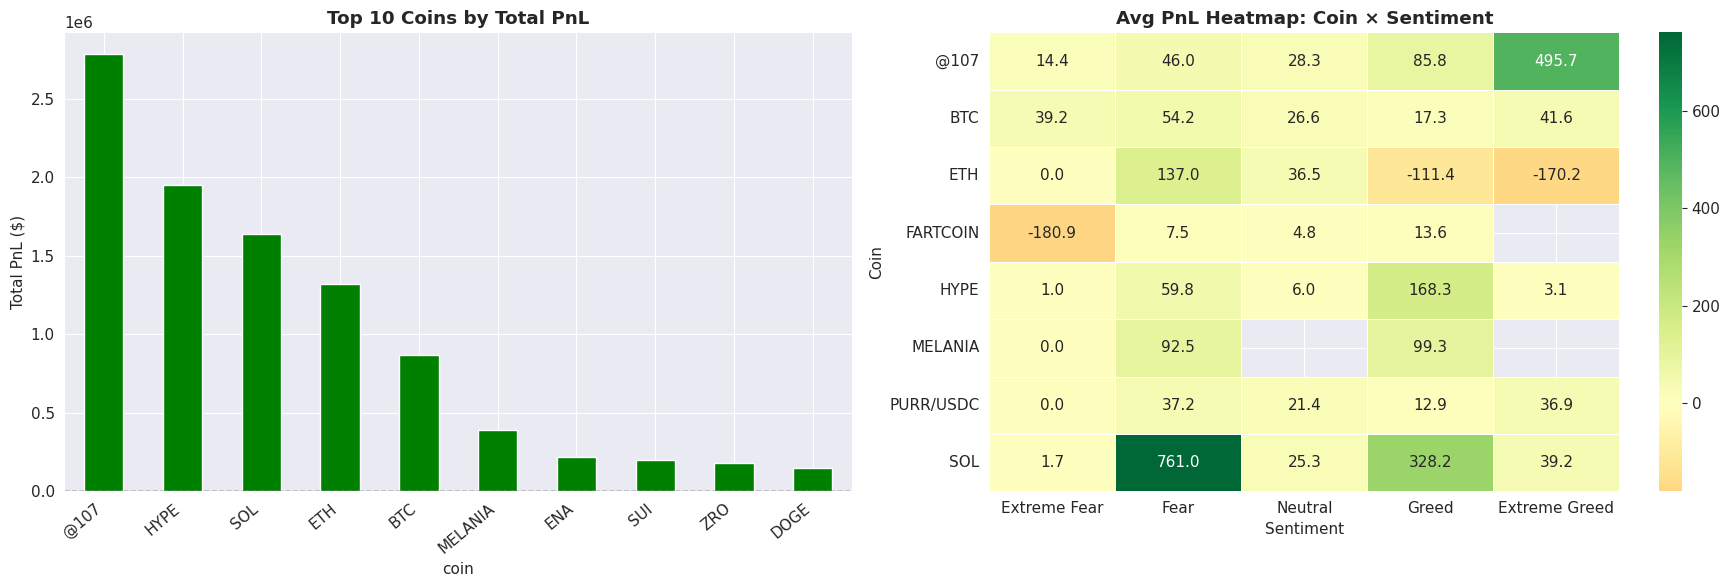

=== TOP 15 TRADERS ===
                                   account    total_pnl    avg_pnl  trade_count  win_rate
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 2.143383e+06 145.481748        14733 33.713432
0x083384f897ee0f19899168e3b1bec365f52a9012 1.600230e+06 419.127768         3818 35.961236
0xbaaaf6571ab7d571043ff1e313a9609a10637864 9.401638e+05  44.364091        21192 46.758211
0x513b8629fe877bb581bf244e326a047b249c4ff1 8.404226e+05  68.684419        12236 40.119320
0xbee1707d6b44d4d52bfe19e41f8a828645437aab 8.360806e+05  20.806305        40184 42.823014
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4 6.777471e+05 155.589314         4356 48.622590
0x72743ae2822edd658c0c50608fd7c5c501b2afbd 4.293556e+05 270.034947         1590 34.591195
0x430f09841d65beb3f27765503d0f850b8bce7713 4.165419e+05 336.735548         1237 48.423605
0x72c6a4624e1dffa724e6d00d64ceae698af892a0 4.030115e+05 281.826227         1430 30.629371
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4 3.790954e+05  38.319560         98

In [29]:
# ---- Top 10 coins by PnL ----
top10_coins = df.groupby('coin')['closed_pnl'].sum().nlargest(10)
coin_colors  = ['green' if v > 0 else 'red' for v in top10_coins.values]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top10_coins.plot(kind='bar', ax=axes[0], color=coin_colors)
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].set_title('Top 10 Coins by Total PnL', fontweight='bold')
axes[0].set_xticklabels(top10_coins.index, rotation=40, ha='right')
axes[0].set_ylabel('Total PnL ($)')

# ---- Coin × Sentiment heatmap ----
top5_coins   = df['coin'].value_counts().head(8).index.tolist()
heatmap_data = (df[df['coin'].isin(top5_coins)]
                .groupby(['coin', 'sentiment'])['closed_pnl']
                .mean()
                .unstack()
                .reindex(columns=existing_order))

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Avg PnL Heatmap: Coin × Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Coin')

plt.tight_layout()
plt.savefig('/content/06_coin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Trader leaderboard ----
trader_stats = df.groupby('account').agg(
    total_pnl   = ('closed_pnl', 'sum'),
    avg_pnl     = ('closed_pnl', 'mean'),
    trade_count = ('closed_pnl', 'count'),
    win_rate    = ('closed_pnl', lambda x: (x > 0).mean() * 100)
).reset_index().sort_values('total_pnl', ascending=False)

print("=== TOP 15 TRADERS ===")
print(trader_stats.head(15).to_string(index=False))

In [30]:
# ---- t-test: Fear vs Greed PnL ----
fear_pnl  = df[df['sentiment'].str.contains('Fear',  na=False)]['closed_pnl'].dropna()
greed_pnl = df[df['sentiment'].str.contains('Greed', na=False)]['closed_pnl'].dropna()

t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl)

print("=" * 60)
print("STATISTICAL TEST — Fear vs Greed")
print("=" * 60)
print(f"Fear  | Mean: ${fear_pnl.mean():.4f}  | N: {len(fear_pnl):,}")
print(f"Greed | Mean: ${greed_pnl.mean():.4f}  | N: {len(greed_pnl):,}")
print(f"T-stat: {t_stat:.4f}  |  P-value: {p_val:.6f}")
print("Result:", "✅ SIGNIFICANT" if p_val < 0.05 else "❌ Not significant at p<0.05")

# ---- Final insight print ----
best_s  = pnl_stats.loc[pnl_stats['avg_pnl'].idxmax(),  'sentiment']
worst_s = pnl_stats.loc[pnl_stats['avg_pnl'].idxmin(),  'sentiment']
best_wr = pnl_stats.loc[pnl_stats['win_rate'].idxmax(), 'sentiment']

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"📈 Best avg PnL sentiment:     {best_s}")
print(f"📉 Worst avg PnL sentiment:    {worst_s}")
print(f"🎯 Highest win-rate sentiment: {best_wr}")

if 'behavior' in df.columns:
    con = df[df['behavior'] == 'Contrarian']['closed_pnl'].mean()
    mom = df[df['behavior'] == 'Momentum']['closed_pnl'].mean()
    print(f"\n🔄 Contrarian avg PnL: ${con:.4f}")
    print(f"📊 Momentum avg PnL:   ${mom:.4f}")
    winner = "CONTRARIAN" if con > mom else "MOMENTUM"
    print(f"👉 {winner} strategy outperforms on this dataset")

print("\n✅ ALL CHARTS SAVED IN /content/")
print("    01_sentiment_overview.png")
print("    02_pnl_by_sentiment.png")
print("    03_long_short_by_sentiment.png")
print("    04_contrarian_momentum.png")
print("    05_lag_effect.png")
print("    06_coin_analysis.png")

STATISTICAL TEST — Fear vs Greed
Fear  | Mean: $110.1343  | N: 16,195
Greed | Mean: $104.4478  | N: 16,913
T-stat: 0.3644  |  P-value: 0.715587
Result: ❌ Not significant at p<0.05

KEY FINDINGS
📈 Best avg PnL sentiment:     Extreme Greed
📉 Worst avg PnL sentiment:    Extreme Fear
🎯 Highest win-rate sentiment: Extreme Greed

🔄 Contrarian avg PnL: $129.9952
📊 Momentum avg PnL:   $32.3619
👉 CONTRARIAN strategy outperforms on this dataset

✅ ALL CHARTS SAVED IN /content/
    01_sentiment_overview.png
    02_pnl_by_sentiment.png
    03_long_short_by_sentiment.png
    04_contrarian_momentum.png
    05_lag_effect.png
    06_coin_analysis.png
